In [1]:
enhanced = False

In [2]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

## Workflow 2 plot: combining three checkpoints

In [4]:
def prepare_df1(df_file, enhanced):
    df = pd.read_csv(df_file).round(2).drop_duplicates('File')

    
    if enhanced:
        df = df.loc[df.File.str.contains('Enhanced')]
    else:
        df = df.loc[~df.File.str.contains('Enhanced')]
    
    size_dict = {
            '12by12': '256 x 256',
            '3by3': '1024 x 1024',
            '6by6': '512 x 512',
            '4by4': '768 x 768'
        }

    ## prepare data for bar chart
    df['Size'] = df.File.apply(lambda x: size_dict[x.split('_')[1]])
    df['size_number'] = df.File.apply(lambda x: int(size_dict[x.split('_')[1]].split(' x ')[0]))
    df.sort_values('size_number', inplace=True)
    
    return df

def prepare_df2(df_file, enhanced):
    df = pd.read_csv(df_file).round(2).drop_duplicates('File')

    size_dict = {
            '12by12': '256 x 256',
            '3by3': '1024 x 1024',
            '6by6': '512 x 512',
            '4by4': '768 x 768'
        }

    ## prepare data for bar chart
    df['Size'] = df.File.apply(lambda x: size_dict[x.split('_')[1]])
    df['size_number'] = df.File.apply(lambda x: int(size_dict[x.split('_')[1]].split(' x ')[0]))
    df['time'] = df.File.apply(lambda x: x.split('_')[0])
    df.sort_values('size_number', inplace=True)
    
    if enhanced:
        return df.loc[df.File.str.contains('Enhanced')]
    else:
        return df.loc[~df.File.str.contains('Enhanced')]
    

infile1 = r'../tables/AGU_Layers/240815_Workflow1_Metrics.csv'
infile2 = r'../tables/AGU_Layers/240815_Workflow2_Metrics.csv'
enhanced = False


df1 = prepare_df1(infile1, enhanced)
df2 = prepare_df2(infile2, enhanced).drop_duplicates(['time', 'size_number'])
df2.head()

,File,Precision,Recall,F1-Score,Detection,IoU,Size,size_number,time
30,T4_12by12_10_segmented_Workflow2Merged_IouGTpo...,0.92,0.11,0.20,10.26,0.69,256 x 256,256,T4
26,T3_12by12_10_segmented_Workflow2Merged_IouGTpo...,0.90,0.11,0.20,9.35,0.68,256 x 256,256,T3
22,T2_12by12_10_segmented_Workflow2Merged_IouGTpo...,0.89,0.08,0.16,6.77,0.67,256 x 256,256,T2
18,T1_12by12_10_segmented_Workflow2Merged_IouGTpo...,0.90,0.07,0.13,6.00,0.70,256 x 256,256,T1
29,T3_6by6_1_segmented_Workflow2Merged_IouGTpoint...,0.90,0.18,0.30,14.39,0.70,512 x 512,512,T3


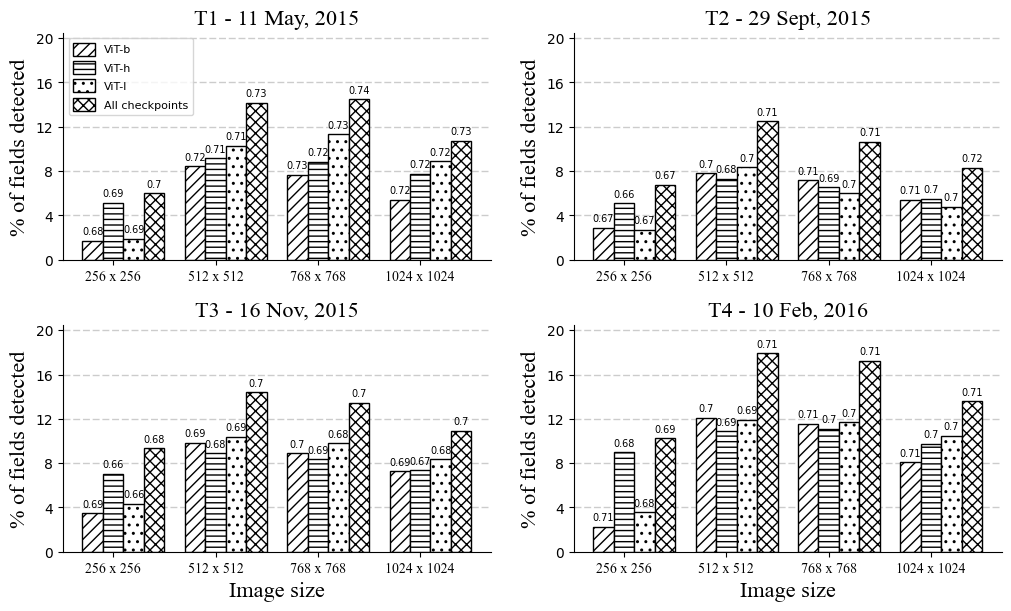

In [5]:
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerPatch

width = 0.2
bar_top_text = 'IoU'

checkpoint_colors = {
    'vit_b': '#7fc97f',
    'vit_h': '#fdc086',
    'vit_l': '#beaed4',
    'Workflow2': '#386cb0'
}

checkpoint_hatches = {
    'vit_b': '///',
    'vit_h': '---',
    'vit_l': '..',
    'Workflow2': 'xxx'
}

label_dict = {
    'vit_b': 'ViT-b',
    'vit_h': 'ViT-h',
    'vit_l': 'ViT-l',
    'Workflow2': 'All checkpoints'
}

time_dict = {
    'T1' : '11 May, 2015',
    'T2' : '29 Sept, 2015',
    'T3' : '16 Nov, 2015',
    'T4' : '10 Feb, 2016'
}

fig, ax = plt.subplots(2, 2, figsize=(10, 6), constrained_layout={'hspace': 0.06, 'wspace': 0.06})
ax = ax.flatten()

for n, epoch in enumerate(['T1', 'T2', 'T3', 'T4']):
    x = np.arange(4) # for four different sizes
    multiplier = 0
    
    # Add dotted lines for the y-axis
    for y_tick in np.arange(4, 22, 4):
        ax[n].axhline(y=y_tick, linestyle=(0, (5, 2)), color='gray', alpha=0.4, linewidth=1, zorder=0)

    for checkpoint in checkpoint_colors.keys():
        offset = width * multiplier
        
        if checkpoint != 'Workflow2':
            temp_df1 = df1.loc[df1.File.str.contains(f'{epoch}_') & df1.File.str.contains(checkpoint)]
            rects = ax[n].bar(x + offset, temp_df1['Detection'], width, 
                              hatch=checkpoint_hatches[checkpoint], edgecolor='black', color='white', label=label_dict[checkpoint])
            ax[n].bar_label(rects, labels=temp_df1[bar_top_text].round(2), padding=3, fontsize='7')
        else:
            temp_df2 = df2.loc[df2.File.str.contains(f'{epoch}_') & df2.File.str.contains(checkpoint)]
            rects = ax[n].bar(x + offset, temp_df2['Detection'], width, 
                              hatch=checkpoint_hatches[checkpoint], edgecolor='black', color='white', label=label_dict[checkpoint])
            ax[n].bar_label(rects, labels=temp_df2[bar_top_text].round(2), padding=3, fontsize='7')

        FONT_FAMILY = 'Times New Roman'
        axis_title_font = {'family': FONT_FAMILY, 'weight': 'normal', 'size': 16}
                
        ax[n].set_xticks(x + width, df2['Size'].unique(), fontfamily='Times New Roman')
        ax[n].set_title(f'{epoch} - {time_dict[epoch]}', fontdict=axis_title_font)
        
        multiplier += 1
        
        ax[n].set_ylabel('% of fields detected', fontdict=axis_title_font)
        if n > 1:
            ax[n].set_xlabel('Image size', fontdict=axis_title_font)

        ax[n].set_ylim(0, 20.5)
        ax[n].set_yticks(np.arange(0, 22, 4), fontdict={'family': FONT_FAMILY})
        ax[n].spines['right'].set_visible(False)
        ax[n].spines['top'].set_visible(False)
        
        if n == 0:
            ax[n].legend(loc='upper left', fontsize=8, handlelength=2, handleheight=1.4)

        
#plt.show()
#plt.savefig(r'../images/AGU_Layers/original_image_size.png', dpi=300, bbox_inches='tight')

## Scatterplot Plot for combined raw and edge enhanced

In [143]:
import geopandas as gpd
from rtree import index
from shapely.geometry import box

infile_gt = r"D:\2212_PlanetOrtho_FieldBoundary\ForPaper\vector\GroundTruth\240805_GroundTruth_FieldBoundaries_PT_V2.shp"
infile_pred = r'D:\2212_PlanetOrtho_FieldBoundary\Vector\230606_Fragments\231210_Workflow6_Output_gtpoint5\RawPlusEdge_Segmented_Workflow6Merged_Combined.gpkg'

gdf_gt = gpd.read_file(infile_gt).explode(index_parts=False).reset_index(inplace=False)
gdf_pred = gpd.read_file(infile_pred).explode(index_parts=False).reset_index()

gdf_pred['max_iou_index'] = -1
gdf_pred['max_iou'] = -1
gdf_pred['max_area'] = -1

In [136]:
gdf_pred = gdf_pred.loc[gdf_pred['ID_pred'] == 4123]
gdf_pred

,index,name,ID_pred,geometry,max_iou_index,max_iou,max_area
2404,2404,AllTime_Segmented_Workflow5Merged_TimeCombined...,4123,"POLYGON ((250904 2818374, 250944 2818374, 2509...",-1,-1,-1


In [ ]:
set1 = [695, 2446]
set2 = [4123, 3651]

In [144]:
%%time

spatial_index = index.Index()
for i, gt_geom in enumerate(gdf_gt.geometry):
    if len(gt_geom.bounds) > 0:
        spatial_index.insert(i, gt_geom.bounds)

def get_bbox_iou(gt_geom, pred_geom):
    intersection_area_bbox = box(*gt_geom.bounds).intersection(box(*pred_geom.bounds)).area
    union_area_bbox = box(*gt_geom.bounds).union(box(*pred_geom.bounds)).area
    
    return intersection_area_bbox / union_area_bbox

        
for idx, pred_row in gdf_pred.iterrows():
    possible_matches_index = list(spatial_index.intersection(pred_row.geometry.bounds))

    possible_matches = gdf_gt.iloc[possible_matches_index]
    precise_matches = possible_matches[possible_matches.intersects(pred_row.geometry)]
    
    # Check if any matches were found to avoid the TypeError
    if not precise_matches.empty:
        gdf_pred.loc[idx, 'max_iou_index'] = precise_matches.geometry.apply(lambda x: get_bbox_iou(x, pred_row.geometry)).idxmax()
        gdf_pred.loc[idx, 'max_iou'] = precise_matches.geometry.apply(lambda x: get_bbox_iou(x, pred_row.geometry)).max()
        gdf_pred.loc[idx, 'max_area'] = gdf_gt.loc[gdf_pred.loc[idx, 'max_iou_index']].geometry.area
    

gdf_pred['area'] = gdf_pred.area
gdf_pred = gdf_pred.drop('index', axis=1)
gdf_pred

CPU times: total: 27.3 s
Wall time: 28.5 s


,name,ID_pred,geometry,max_iou_index,max_iou,max_area,area
0,AllTime_Segmented_Workflow5Merged_TimeCombined...,1,"POLYGON ((251992 2817738, 251994 2817738, 2519...",6200,0.588688,358.218802,328.0
1,AllTime_Segmented_Workflow5Merged_TimeCombined...,3,"POLYGON ((251928 2818948, 251930 2818948, 2519...",6176,0.688361,1118.488316,1545.0
2,AllTime_Segmented_Workflow5Merged_TimeCombined...,4,"POLYGON ((252246 2818252, 252256 2818252, 2522...",7527,0.738529,248.672831,261.0
3,AllTime_Segmented_Workflow5Merged_TimeCombined...,5,"POLYGON ((252378 2818239, 252388 2818239, 2523...",5089,0.117604,1388.076697,322.0
4,AllTime_Segmented_Workflow5Merged_TimeCombined...,6,"POLYGON ((250100 2819982, 250104 2819982, 2501...",1215,0.778051,320.425288,456.0
...,...,...,...,...,...,...,...
4856,AllTime_Segmented_Workflow5Merged_TimeCombined...,8700,"POLYGON ((252144 2817913, 252145 2817913, 2521...",6110,0.852669,223.872417,218.0
4857,AllTime_Segmented_Workflow5Merged_TimeCombined...,8701,"POLYGON ((252188 2817562, 252193 2817562, 2521...",4583,0.150624,613.154451,119.0
4858,AllTime_Segmented_Workflow5Merged_TimeCombined...,8702,"POLYGON ((250519 2818083, 250519 2818082, 2505...",2812,0.591725,2000.027849,1375.0
4859,AllTime_Segmented_Workflow5Merged_TimeCombined...,8703,"POLYGON ((251516 2817957, 251515 2817957, 2515...",5547,0.789517,548.606224,506.0


In [138]:
precise_matches

,index,fid,id,layer,area,NDVI_mean,geometry
3577,3571,4399.0,4401.0,kyle_boundaries_v2,1115.446,0.777434,"POLYGON ((250930.964 2818342.357, 250966.995 2..."
3581,3575,4403.0,4405.0,kyle_boundaries_v2,2477.680,0.749255,"POLYGON ((250846.861 2818330.628, 250849.752 2..."
3651,3643,4480.0,4482.0,kyle_boundaries_v2,5628.067,0.691833,"POLYGON ((250907.169 2818398.756, 250947.038 2..."
3653,3645,4482.0,4484.0,kyle_boundaries_v2,2574.383,0.711270,"POLYGON ((250906.18 2818399.424, 250905.891 28..."
3106,3100,3759.0,3759.0,kyle_boundaries_v2,2741.400,0.807701,"POLYGON ((250888.333 2818283.692, 250888.333 2..."


<Axes: >

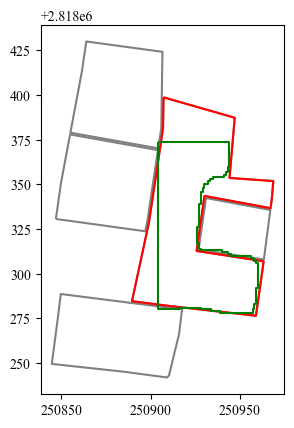

In [142]:
ax = precise_matches.loc[precise_matches['index'] != 3651].boundary.plot(color='gray')
precise_matches.loc[precise_matches['index'] == 3643].boundary.plot(color='red', ax=ax)
gdf_pred.boundary.plot(ax=ax, color='green')

C:\Users\ptripathy\AppData\Local\Temp\ipykernel_24268\2800338449.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\2212_PlanetOrtho_FieldBoundary\\ForPaper\\images\\paper\\scatterplot_v2.png'

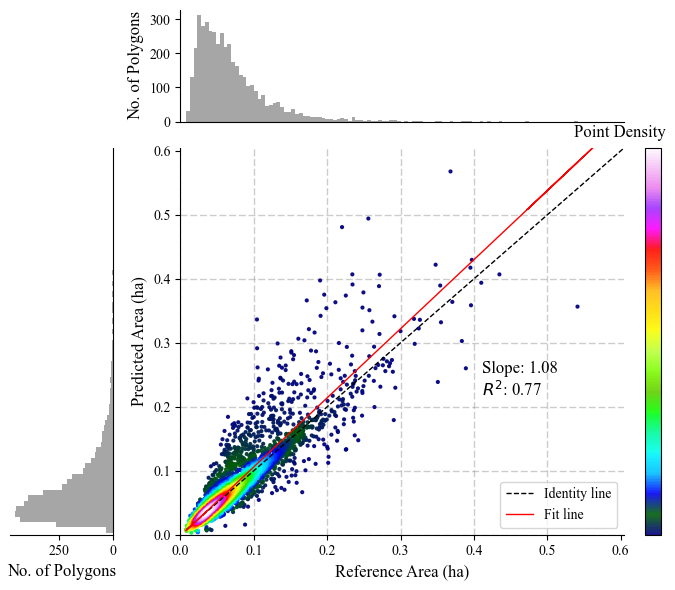

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score
import geopandas as gpd
import matplotlib as mpl

# Set font to Times New Roman
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

# Load your data
gdf_subset = gdf_pred.loc[gdf_pred.max_iou > 0.5].reset_index()

x = gdf_subset['max_area'] / 10000
y = gdf_subset['area'] / 10000  # Convert m2 to hectares

# Calculate R-squared
r2 = r2_score(x, y)

# Set up the figure and gridspec
fig = plt.figure(figsize=(6.5, 6))
gs = GridSpec(4, 4, figure=fig)

# Define the axes
ax_main = fig.add_subplot(gs[1:4, 1:4])
ax_xhist = fig.add_subplot(gs[0, 1:4], sharex=ax_main)
ax_yhist = fig.add_subplot(gs[1:4, 0], sharey=ax_main)

# Scatter plot on main axes
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]
scatter_plot = ax_main.scatter(x, y, alpha=0.9, c=z, s=4, cmap='gist_ncar')

# Add dotted lines for the y-axis
for y_tick in np.arange(0, 0.6000, 0.1000):
    ax_main.axhline(y=y_tick, linestyle=(0, (5, 2)), color='gray', alpha=0.4, linewidth=1, zorder=0)
    ax_main.axvline(x=y_tick, linestyle=(0, (5, 2)), color='gray', alpha=0.4, linewidth=1, zorder=0)

# Add colormap
max_z = max(z)
min_z = min(z)
cbar_ax = fig.add_axes([1, 0.1, 0.025, 0.645])
cbar = fig.colorbar(scatter_plot, cax=cbar_ax)
cbar.set_ticks([min_z, max_z])
cbar.set_ticklabels(["Low", "High"])
cbar.set_label('Point Density', labelpad=-30, y=1.06, rotation=0, fontsize=12)

# Histogram on the x axis
ax_xhist.hist(x, bins=150, alpha=0.7, color='gray')

# Histogram on the y axis
ax_yhist.hist(y, bins=150, orientation='horizontal', alpha=0.7, color='gray')
ax_yhist.invert_xaxis()

# Hide x axis info for top plot and y axis info for right plot
ax_xhist.xaxis.set_visible(False)
ax_yhist.yaxis.set_visible(False)

# Add regression and identity lines to main plot
ax_main.plot([x.min(), x.max()], [x.min(), x.max()], 'k--', lw=1, label='Identity line')
m, b = np.polyfit(x, y, 1)
ax_main.plot(x, m*x + b, 'r-', label='Fit line', linewidth=1)

# add R2 and slope value to the plot
r2 = r2_score(y, m * x + b)

# Add text for slope and R2
ax_main.text(0.68, 0.45, f'Slope: {m:.2f}', transform=ax_main.transAxes, fontsize=12, verticalalignment='top')
ax_main.text(0.68, 0.4, f'$R^2$: {r2:.2f}', transform=ax_main.transAxes, fontsize=12, verticalalignment='top')

# Labels and titles
ax_main.set_xlabel('Reference Area (ha)', fontsize=12)
ax_main.set_ylabel('Predicted Area (ha)', fontsize=12)
ax_xhist.set_ylabel('No. of Polygons', fontsize=12)
ax_yhist.set_xlabel('No. of Polygons', fontsize=12)

# Disable grid on the histograms
ax_xhist.grid(False)
ax_yhist.grid(False)

# Adjusting spines visibility
for ax in [ax_main, ax_xhist, cbar_ax]:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(False)

ax_yhist.spines['left'].set_visible(False)
ax_yhist.spines['top'].set_visible(False)

# Adjust the colorbar axis
cbar_ax.spines['left'].set_visible(False)
cbar_ax.spines['bottom'].set_visible(False)
cbar_ax.set_xticks([])  # Removes x-axis ticks
cbar_ax.set_yticks([])

ax_main.set_xlim(0, 0.6050)
ax_main.set_ylim(0, 0.6050)

ax_main.legend(loc='lower right', frameon=True)

# Show the plot
plt.tight_layout()
plt.savefig(r'../images/paper/scatterplot_v2.png', dpi=300, bbox_inches='tight')

C:\Users\ptripathy\AppData\Local\miniforge-pypy3\envs\defor39\lib\site-packages\geopandas\geodataframe.py:1750: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
C:\Users\ptripathy\AppData\Local\Temp\ipykernel_24268\2150757876.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


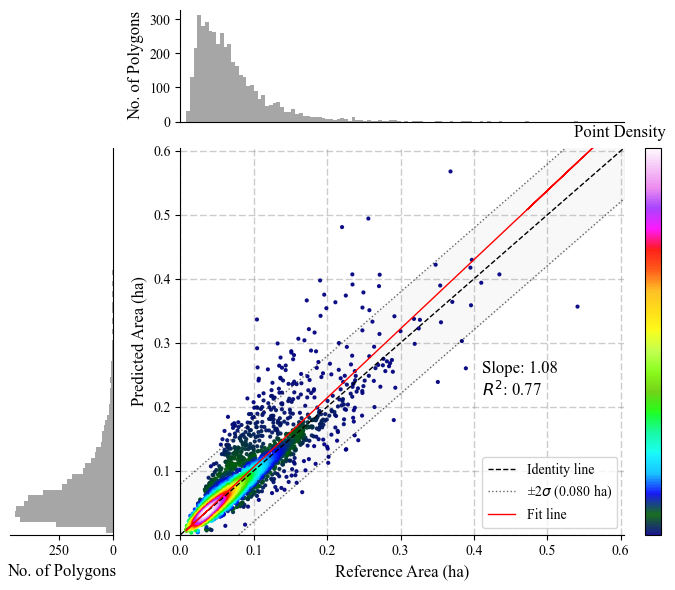

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score
import geopandas as gpd
import matplotlib as mpl

# Set font to Times New Roman
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

# Load your data
gdf_subset = gdf_pred.loc[gdf_pred.max_iou > 0.5].reset_index()

x = gdf_subset['max_area'] / 10000
y = gdf_subset['area'] / 10000  # Convert m2 to hectares

# Calculate R-squared
r2 = r2_score(x, y)

# Set up the figure and gridspec
fig = plt.figure(figsize=(6.5, 6))
gs = GridSpec(4, 4, figure=fig)

# Define the axes
ax_main = fig.add_subplot(gs[1:4, 1:4])
ax_xhist = fig.add_subplot(gs[0, 1:4], sharex=ax_main)
ax_yhist = fig.add_subplot(gs[1:4, 0], sharey=ax_main)

# Scatter plot on main axes
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]
scatter_plot = ax_main.scatter(x, y, alpha=0.9, c=z, s=4, cmap='gist_ncar')

# Add dotted lines for the grid
for tick in np.arange(0, 0.7, 0.1):
    ax_main.axhline(y=tick, linestyle=(0, (5, 2)), color='gray', alpha=0.4, linewidth=1, zorder=0)
    ax_main.axvline(x=tick, linestyle=(0, (5, 2)), color='gray', alpha=0.4, linewidth=1, zorder=0)

# Add colormap
max_z = max(z)
min_z = min(z)
cbar_ax = fig.add_axes([1, 0.1, 0.025, 0.645])
cbar = fig.colorbar(scatter_plot, cax=cbar_ax)
cbar.set_ticks([min_z, max_z])
cbar.set_ticklabels(["Low", "High"])
cbar.set_label('Point Density', labelpad=-30, y=1.06, rotation=0, fontsize=12)

# Histogram on the x axis
ax_xhist.hist(x, bins=150, alpha=0.7, color='gray')

# Histogram on the y axis
ax_yhist.hist(y, bins=150, orientation='horizontal', alpha=0.7, color='gray')
ax_yhist.invert_xaxis()

# Hide x axis info for top plot and y axis info for right plot
ax_xhist.xaxis.set_visible(False)
ax_yhist.yaxis.set_visible(False)

# Add Identity Line
limit_val = 0.6050
ax_main.plot([0, limit_val], [0, limit_val], 'k--', lw=1, label='Identity line')

# --- CALCULATE STANDARD DEVIATION THRESHOLD ---
residuals = y - x
std_dev = np.std(residuals)
threshold = 2.5 * std_dev  # 2-sigma threshold
line_x = np.array([0, limit_val])

# Identify outliers in the dataframe
outlier_mask = np.abs(residuals) > threshold
df_outliers = gdf_subset[outlier_mask]

# Add Sigma Bound Lines
ax_main.plot(line_x, line_x + threshold, 'k:', lw=1, alpha=0.6, label=f'±2$\sigma$ ({threshold:.3f} ha)')
ax_main.plot(line_x, line_x - threshold, 'k:', lw=1, alpha=0.6)

# Shade the area within bounds
ax_main.fill_between(line_x, line_x - threshold, line_x + threshold, color='gray', alpha=0.05, zorder=0)

# Add regression line
m, b = np.polyfit(x, y, 1)
ax_main.plot(x, m*x + b, 'r-', label='Fit line', linewidth=1)

# recalculate R2 and slope value
r2 = r2_score(y, m * x + b)

# Add text for slope, R2, and SD
ax_main.text(0.68, 0.45, f'Slope: {m:.2f}', transform=ax_main.transAxes, fontsize=12, verticalalignment='top')
ax_main.text(0.68, 0.4, f'$R^2$: {r2:.2f}', transform=ax_main.transAxes, fontsize=12, verticalalignment='top')

# Labels and titles
ax_main.set_xlabel('Reference Area (ha)', fontsize=12)
ax_main.set_ylabel('Predicted Area (ha)', fontsize=12)
ax_xhist.set_ylabel('No. of Polygons', fontsize=12)
ax_yhist.set_xlabel('No. of Polygons', fontsize=12)

# Disable grid on the histograms
ax_xhist.grid(False)
ax_yhist.grid(False)

# Adjusting spines visibility
for ax in [ax_main, ax_xhist, cbar_ax]:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(False)

ax_yhist.spines['left'].set_visible(False)
ax_yhist.spines['top'].set_visible(False)

# Adjust the colorbar axis
cbar_ax.spines['left'].set_visible(False)
cbar_ax.spines['bottom'].set_visible(False)
cbar_ax.set_xticks([])  
cbar_ax.set_yticks([])

ax_main.set_xlim(0, limit_val)
ax_main.set_ylim(0, limit_val)

# Update legend
ax_main.legend(loc='lower right', frameon=True)

# Show the plot
plt.tight_layout()
plt.show()

In [126]:
gdf_subset.sort_values('max_area', ascending=False)

,index,name,ID_pred,geometry,max_iou_index,max_iou,max_area,area
3845,4264,AllTime_Segmented_Workflow5Merged_TimeCombined...,7523,"POLYGON ((251632 2817658, 251639 2817658, 2516...",3264,0.627402,7773.755761,4944.0
501,532,AllTime_Segmented_Workflow5Merged_TimeCombined...,908,"POLYGON ((251327 2817800, 251327 2817799, 2513...",3455,0.848524,6776.315902,6679.0
2202,2404,AllTime_Segmented_Workflow5Merged_TimeCombined...,4123,"POLYGON ((250904 2818374, 250944 2818374, 2509...",3651,0.555217,5411.937590,3566.0
650,695,AllTime_Segmented_Workflow5Merged_TimeCombined...,1192,"POLYGON ((250427 2819806, 250426 2819806, 2504...",2451,0.652487,4726.956601,12606.0
1309,1418,AllTime_Segmented_Workflow5Merged_TimeCombined...,2493,"POLYGON ((251414 2819385, 251417 2819385, 2514...",1635,0.508732,4347.590414,4070.0
...,...,...,...,...,...,...,...,...
3821,4222,AllTime_Segmented_Workflow5Merged_TimeCombined...,7453,"POLYGON ((251649 2818908, 251656 2818908, 2516...",6823,0.817133,93.580467,101.0
3365,3693,AllTime_Segmented_Workflow5Merged_TimeCombined...,6414,"POLYGON ((251767 2819021, 251782 2819021, 2517...",6356,0.564208,88.222259,142.0
3796,4192,AllTime_Segmented_Workflow5Merged_TimeCombined...,7396,"POLYGON ((250606 2819633, 250608 2819633, 2506...",2614,0.521458,84.557749,58.0
24,34,AllTime_Segmented_Workflow5Merged_TimeCombined...,50,"POLYGON ((252444 2819101, 252449 2819101, 2524...",6587,0.749975,81.717585,78.0


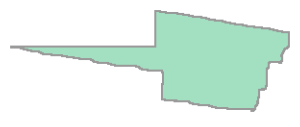

In [43]:
gdf_pred.iloc[695]['geometry']

In [61]:
gdf_gt.loc[gdf_gt['index'] == 2451]

,index,fid,id,layer,area,NDVI_mean,geometry
2457,2451,3020.0,3020.0,jyles_field_updated,576.287,0.225649,"POLYGON ((250220.047 2819958.338, 250217.652 2..."
